# Penny Transaction Data Exploration

This notebook explores the synthetic penny transaction dataset to understand:
- Hourly penny transaction count patterns
- Daily/weekly cycles and periodicity
- Normal vs anomaly periods
- Why frequency-based detection is appropriate for this data

We use an **FCVAE (Frequency-enhanced Conditional Variational Autoencoder)** — a VAE that conditions on frequency-domain features to learn periodic patterns in time series data. The frequency features are extracted via **FFT (Fast Fourier Transform)**, a mathematical operation that decomposes a signal into its constituent periodic components (e.g., daily cycles, semi-daily patterns). The FCVAE uses two frequency conditioning modules:

- **GFM (Global Frequency Module)**: applies FFT to the entire 24-hour window to capture the dominant periodic structure across the full day
- **LFM (Local Frequency Module)**: applies FFT to smaller 8-hour sub-windows and uses self-attention to capture shorter-range, local frequency trends

This notebook motivates why penny transactions are well-suited for this approach by showing the strong periodic structure in the data.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _ in range(5):
    if (PROJECT_ROOT / "pyproject.toml").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "pyproject.toml").exists(), (
    f"Could not find project root. CWD={Path.cwd()}\n"
    "Please run: uv run jupyter notebook   (from the project root)"
)
sys.path.insert(0, str(PROJECT_ROOT))

import logging
for name in ["src.model", "src.scorer", "src.preprocess", "src.train"]:
    logging.getLogger(name).setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")

## 1. Load and Filter Penny Transactions

Penny transactions are those with `amount < $1.00`, pooled across all network types and transaction types.

In [2]:
# Load raw data
csv_path = DATA_DIR / "synthetic_transactions.csv"
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
print(f"Total transactions: {len(df):,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nAmount distribution:")
print(df["amount"].describe())

Total transactions: 8,852,859
Date range: 2025-01-06 00:00:01.054827896 to 2025-03-06 23:59:59.962628687

Columns: ['timestamp', 'network_type', 'transaction_type', 'amount', 'is_anomaly', 'penny_is_anomaly', 'split']

Amount distribution:
count    8.852859e+06
mean     3.596923e+01
std      4.101746e+01
min      1.000000e-02
25%      1.271000e+01
50%      2.390000e+01
75%      4.431000e+01
max      2.662230e+03
Name: amount, dtype: float64


In [3]:
# Filter to penny transactions
penny_df = df[df["amount"] < 1.00].copy()
print(f"Penny transactions: {len(penny_df):,} ({len(penny_df)/len(df)*100:.2f}%)")
print(f"\nAmount stats (penny only):")
print(penny_df["amount"].describe())

Penny transactions: 203,827 (2.30%)

Amount stats (penny only):
count    203827.000000
mean          0.307458
std           0.288171
min           0.010000
25%           0.010000
50%           0.350000
75%           0.500000
max           0.990000
Name: amount, dtype: float64


In [4]:
# Aggregate to hourly penny counts
penny_df["hour_bucket"] = penny_df["timestamp"].dt.floor("h")

anomaly_col = "penny_is_anomaly" if "penny_is_anomaly" in penny_df.columns else "is_anomaly"
print(f"Using anomaly column: {anomaly_col}")

hourly = penny_df.groupby("hour_bucket").agg(
    count=("timestamp", "count"),
    is_anomaly=(anomaly_col, "max")
).reset_index()

# Fill missing hours with 0
full_hours = pd.date_range(start=hourly["hour_bucket"].min(), end=hourly["hour_bucket"].max(), freq="h")
hourly = pd.DataFrame({"hour_bucket": full_hours}).merge(hourly, on="hour_bucket", how="left")
hourly["count"] = hourly["count"].fillna(0).astype(int)
hourly["is_anomaly"] = hourly["is_anomaly"].fillna(0).astype(int)

print(f"\nHourly data: {len(hourly)} hours ({len(hourly)//24} days)")
print(f"Mean hourly count: {hourly['count'].mean():.1f}")
print(f"Anomaly hours: {hourly['is_anomaly'].sum()}")

Using anomaly column: penny_is_anomaly

Hourly data: 1440 hours (60 days)
Mean hourly count: 141.5
Anomaly hours: 14


## 2. Hourly Penny Count Patterns

Plot the full 60-day penny transaction count time series. Training, validation, and test regions are shaded.

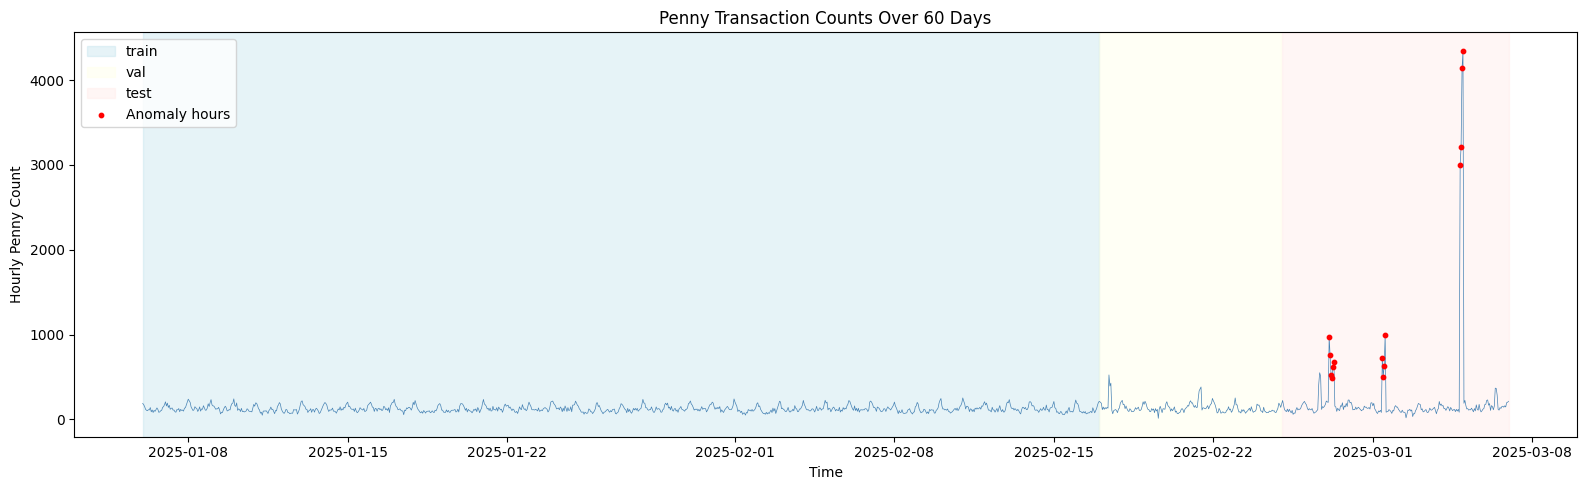

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(hourly["hour_bucket"], hourly["count"], linewidth=0.5, color="steelblue")

# Shade splits if available
if "split" in df.columns:
    penny_splits = penny_df.groupby("hour_bucket")["split"].first()
    hourly_with_split = hourly.merge(
        penny_splits.reset_index().rename(columns={"split": "data_split"}),
        on="hour_bucket", how="left"
    )
    hourly_with_split["data_split"] = hourly_with_split["data_split"].ffill().bfill()
    
    for split_name, color in [("train", "lightblue"), ("val", "lightyellow"), ("test", "mistyrose")]:
        mask = hourly_with_split["data_split"] == split_name
        if mask.sum() > 0:
            start = hourly_with_split.loc[mask, "hour_bucket"].min()
            end = hourly_with_split.loc[mask, "hour_bucket"].max()
            ax.axvspan(start, end, alpha=0.3, color=color, label=split_name)

# Highlight anomaly hours
anomaly_mask = hourly["is_anomaly"] == 1
if anomaly_mask.sum() > 0:
    ax.scatter(hourly.loc[anomaly_mask, "hour_bucket"], hourly.loc[anomaly_mask, "count"],
               color="red", s=10, zorder=5, label="Anomaly hours")

ax.set_xlabel("Time")
ax.set_ylabel("Hourly Penny Count")
ax.set_title("Penny Transaction Counts Over 60 Days")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Daily Periodicity

Overlay multiple days to show the repeating hourly pattern. Penny transactions follow a clear diurnal cycle.

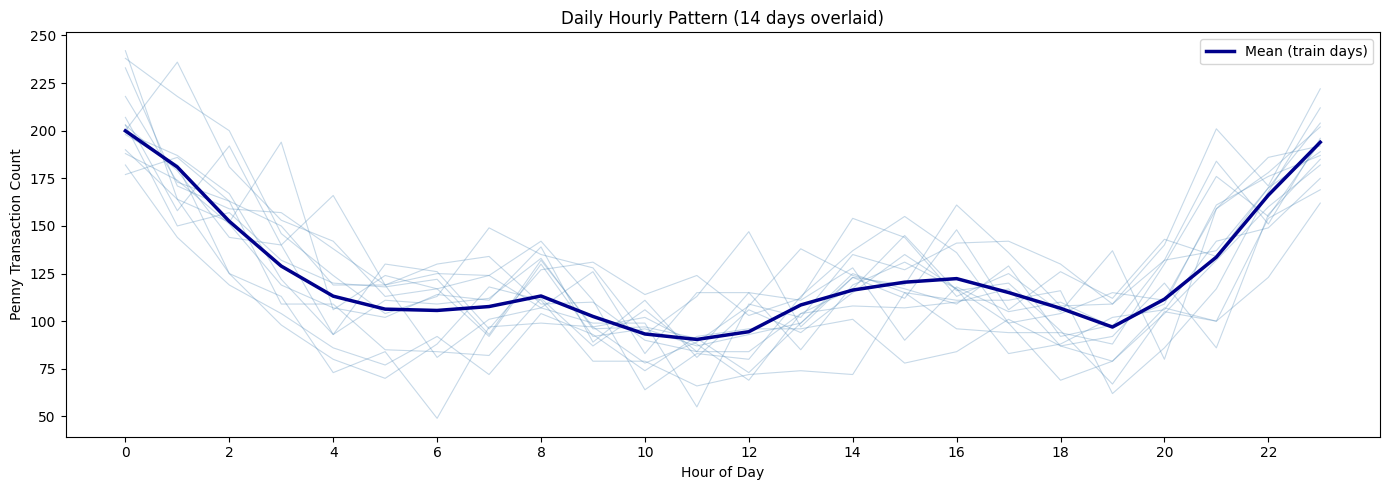

In [6]:
counts = hourly["count"].values
num_days = len(counts) // 24

fig, ax = plt.subplots(figsize=(14, 5))

# Plot first 14 normal days
for d in range(min(14, num_days)):
    day_counts = counts[d * 24 : (d + 1) * 24]
    ax.plot(range(24), day_counts, alpha=0.3, color="steelblue", linewidth=0.8)

# Plot mean
daily_matrix = counts[:min(42, num_days) * 24].reshape(-1, 24)
mean_day = daily_matrix.mean(axis=0)
ax.plot(range(24), mean_day, color="darkblue", linewidth=2.5, label="Mean (train days)")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Penny Transaction Count")
ax.set_title("Daily Hourly Pattern (14 days overlaid)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 4. Frequency Analysis (FFT)

The **FFT (Fast Fourier Transform)** decomposes a time series into a sum of sine waves at different frequencies. Each frequency component has a magnitude (how strong that cycle is) and a period (how long one cycle takes). For example, a strong component at period=24h means the data has a prominent daily cycle.

This is exactly what the FCVAE's **GFM (Global Frequency Module)** does internally — it applies FFT to each input window and embeds the result as a conditioning signal. The **LFM (Local Frequency Module)** does the same on 8-hour sub-windows to capture shorter-range patterns.

Below we apply FFT to the training data to see which frequencies dominate.

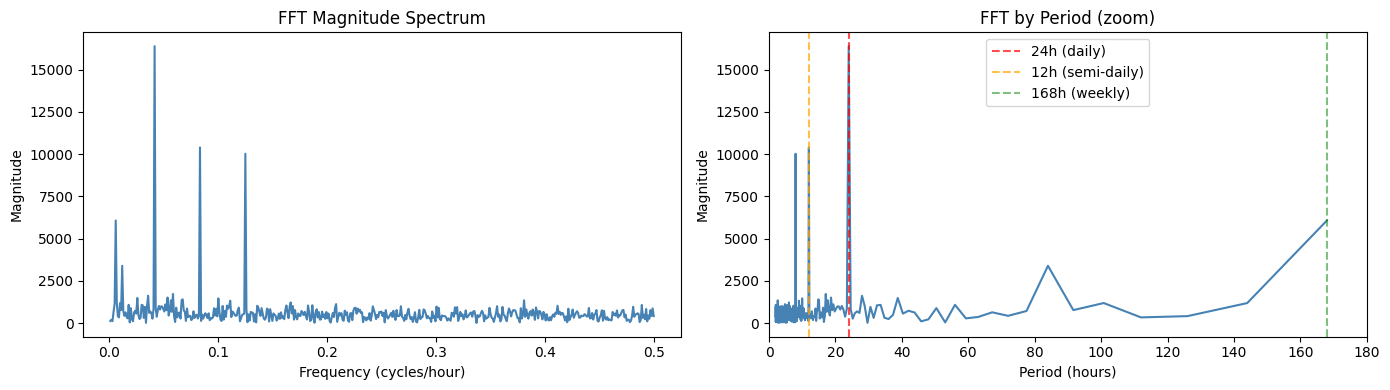

Top 5 frequency components:
  Period: 24.0h, Magnitude: 16388.9
  Period: 12.0h, Magnitude: 10393.8
  Period: 8.0h, Magnitude: 10024.2
  Period: 168.0h, Magnitude: 6075.5
  Period: 84.0h, Magnitude: 3396.0


In [7]:
# Use only training period for FFT
train_counts = counts[:42 * 24].astype(np.float64)
train_counts -= train_counts.mean()

fft_vals = np.fft.rfft(train_counts)
fft_magnitude = np.abs(fft_vals)
freqs = np.fft.rfftfreq(len(train_counts), d=1.0)  # d=1 hour

# Convert to period in hours (skip DC component at index 0)
periods = np.zeros_like(freqs)
periods[0] = np.inf
periods[1:] = 1.0 / freqs[1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Full spectrum (skip DC)
ax1.plot(freqs[1:], fft_magnitude[1:], color="steelblue")
ax1.set_xlabel("Frequency (cycles/hour)")
ax1.set_ylabel("Magnitude")
ax1.set_title("FFT Magnitude Spectrum")

# Zoom to meaningful periods
mask = (periods > 1) & (periods < 200)
ax2.plot(periods[mask], fft_magnitude[mask], color="steelblue")
ax2.axvline(24, color="red", linestyle="--", alpha=0.7, label="24h (daily)")
ax2.axvline(12, color="orange", linestyle="--", alpha=0.7, label="12h (semi-daily)")
ax2.axvline(168, color="green", linestyle="--", alpha=0.5, label="168h (weekly)")
ax2.set_xlabel("Period (hours)")
ax2.set_ylabel("Magnitude")
ax2.set_title("FFT by Period (zoom)")
ax2.legend()
ax2.set_xlim(0, 180)

plt.tight_layout()
plt.show()

# Top frequencies
top_idx = np.argsort(fft_magnitude[1:])[-5:][::-1] + 1
print("Top 5 frequency components:")
for idx in top_idx:
    print(f"  Period: {periods[idx]:.1f}h, Magnitude: {fft_magnitude[idx]:.1f}")

## 5. Normal vs Anomaly Periods

The test set (days 51-60) contains injected anomalies: 5x spike (mild), 10x spike (moderate), and 25x spike (severe).

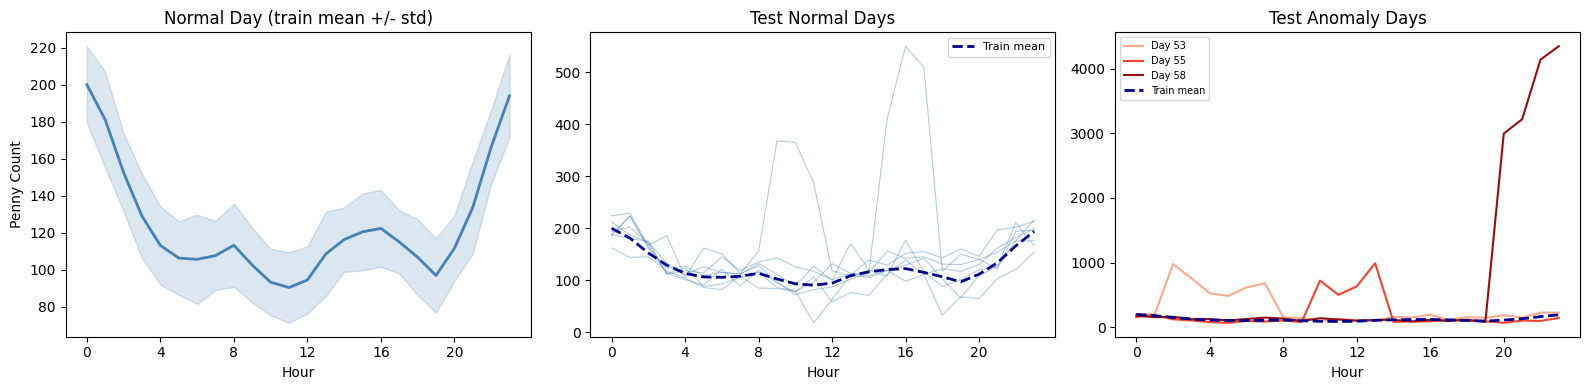

In [8]:
# Compare normal days vs anomaly days
normal_daily = counts[:42 * 24].reshape(-1, 24)  # Train period

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Normal day
ax = axes[0]
normal_mean = normal_daily.mean(axis=0)
normal_std = normal_daily.std(axis=0)
ax.plot(range(24), normal_mean, color="steelblue", linewidth=2)
ax.fill_between(range(24), normal_mean - normal_std, normal_mean + normal_std, alpha=0.2, color="steelblue")
ax.set_title("Normal Day (train mean +/- std)")
ax.set_xlabel("Hour")
ax.set_ylabel("Penny Count")
ax.set_xticks(range(0, 24, 4))

# Test period - find anomaly days
test_start = 50 * 24  # Day 51 (0-indexed day 50)
test_hours = len(counts) - test_start
test_days = test_hours // 24

if test_days > 0:
    test_daily = counts[test_start:test_start + test_days * 24].reshape(-1, 24)
    test_anomalies = hourly["is_anomaly"].values[test_start:test_start + test_days * 24].reshape(-1, 24)
    
    # Anomaly days
    anomaly_day_mask = test_anomalies.sum(axis=1) > 0
    normal_day_mask = ~anomaly_day_mask
    
    ax = axes[1]
    if normal_day_mask.sum() > 0:
        for d in range(len(test_daily)):
            if normal_day_mask[d]:
                ax.plot(range(24), test_daily[d], alpha=0.4, color="steelblue", linewidth=0.8)
    ax.plot(range(24), normal_mean, color="darkblue", linewidth=2, linestyle="--", label="Train mean")
    ax.set_title("Test Normal Days")
    ax.set_xlabel("Hour")
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=8)
    
    ax = axes[2]
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, max(1, anomaly_day_mask.sum())))
    ci = 0
    for d in range(len(test_daily)):
        if anomaly_day_mask[d]:
            ax.plot(range(24), test_daily[d], color=colors[ci], linewidth=1.5, label=f"Day {d + 51}")
            ci += 1
    ax.plot(range(24), normal_mean, color="darkblue", linewidth=2, linestyle="--", label="Train mean")
    ax.set_title("Test Anomaly Days")
    ax.set_xlabel("Hour")
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 6. Hourly Count Distributions

Compare the distribution of hourly counts during normal vs anomalous periods.

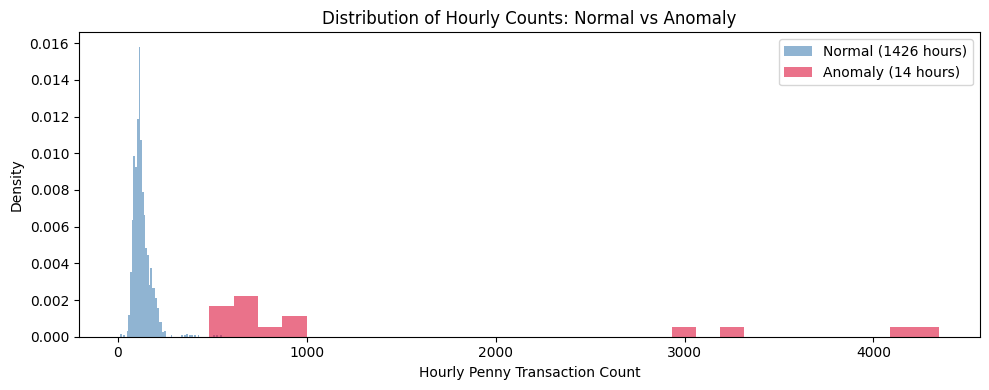

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

normal_mask = hourly["is_anomaly"] == 0
anomaly_mask = hourly["is_anomaly"] == 1

ax.hist(hourly.loc[normal_mask, "count"], bins=60, alpha=0.6, color="steelblue",
        label=f"Normal ({normal_mask.sum()} hours)", density=True)
if anomaly_mask.sum() > 0:
    ax.hist(hourly.loc[anomaly_mask, "count"], bins=30, alpha=0.6, color="crimson",
            label=f"Anomaly ({anomaly_mask.sum()} hours)", density=True)

ax.set_xlabel("Hourly Penny Transaction Count")
ax.set_ylabel("Density")
ax.set_title("Distribution of Hourly Counts: Normal vs Anomaly")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Penny transactions show:
- **Clear hourly periodicity** — strong 24h cycle visible in both time domain and FFT
- **Consistent daily patterns** — repeating low-count overnight, peak during business hours
- **Anomaly periods with elevated counts** — 5x/10x/25x spike injections break the learned frequency pattern

This makes penny transactions an excellent fit for the **FCVAE (Frequency-enhanced Conditional Variational Autoencoder)**, which explicitly models periodic patterns via **FFT (Fast Fourier Transform)** conditioning through its **GFM (Global Frequency Module)** and **LFM (Local Frequency Module)**, and detects anomalies as deviations from the learned frequency structure.